---
##Importación de librerías


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Librerías importadas correctamente.")

Librerías importadas correctamente.



## ACTIVIDAD 1 — Preparación e Inspección Inicial del Dataset

### PASO 1.1 — Carga del dataset


In [2]:
# URL del archivo en GitHub
url = "https://raw.githubusercontent.com/RodrigoARivasG/dataminig_2509642022/refs/heads/main/archivos/Prestige_modificado.csv"

# Carga del CSV con separador de punto y coma
df = pd.read_csv(url, sep=';')

print("Archivo cargado correctamente.")
print(f"Registros cargados: {df.shape[0]} filas x {df.shape[1]} columnas")

Archivo cargado correctamente.
Registros cargados: 102 filas x 7 columnas


### PASO 1.2 — Vista previa de los datos


In [3]:
# Primeras 5 filas del dataset
print("Vista previa del dataset:")
print(df.head(10))

Vista previa del dataset:
            occupation  education  income  women  prestige  census  type_num
0   gov.administrators      13.11   12351  11.16      68.8    1113         1
1     general.managers      12.26   25879   4.02      69.1    1130         1
2          accountants      12.77    9271  15.70      63.4    1171         1
3  purchasing.officers      11.42    8865   9.11      56.8    1175         1
4             chemists      14.62    8403  11.68      73.5    2111         1
5           physicists      15.64   11030   5.13      77.6    2113         1
6           biologists      15.09    8258  25.65      72.6    2133         1
7           architects      15.44   14163   2.69      78.1    2141         1
8      civil.engineers      14.52   11377   1.03      73.1    2143         1
9     mining.engineers      14.64   11023   0.94      68.8    2153         1


### PASO 1.3 — Dimensiones y nombres de columnas



In [4]:
print("\nDimensiones del dataset:")
print(f"  Filas: {df.shape[0]}")
print(f"  Columnas: {df.shape[1]}")

print("\nNombres de columnas:")
print(df.columns.tolist())


Dimensiones del dataset:
  Filas: 102
  Columnas: 7

Nombres de columnas:
['occupation', 'education', 'income', 'women', 'prestige', 'census', 'type_num']


### PASO 1.4 — Tipos de datos e información general


In [5]:
print("Información general del dataset:")
print(df.info())

print("\nTipos de datos por columna:")
print(df.dtypes)

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   occupation  102 non-null    object 
 1   education   102 non-null    float64
 2   income      102 non-null    int64  
 3   women       102 non-null    float64
 4   prestige    102 non-null    float64
 5   census      102 non-null    int64  
 6   type_num    102 non-null    int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 5.7+ KB
None

Tipos de datos por columna:
occupation     object
education     float64
income          int64
women         float64
prestige      float64
census          int64
type_num        int64
dtype: object


### PASO 1.5 — Revisión de valores nulos y duplicados



In [6]:
print("Valores nulos por columna:")
print(df.isnull().sum())

print(f"\nRegistros duplicados: {df.duplicated().sum()}")

# Interpretación automática
if df.isnull().sum().sum() == 0 and df.duplicated().sum() == 0:
    print("\nEl dataset no tiene valores nulos ni duplicados. Está listo para análisis.")
else:
    print("\nSe detectaron problemas de calidad. Revisar antes de continuar.")

Valores nulos por columna:
occupation    0
education     0
income        0
women         0
prestige      0
census        0
type_num      0
dtype: int64

Registros duplicados: 0

El dataset no tiene valores nulos ni duplicados. Está listo para análisis.


### PASO 1.6 — Estadística descriptiva


In [7]:
print("Estadística descriptiva de variables numéricas:")
print(df.describe().round(2))

Estadística descriptiva de variables numéricas:
       education    income   women  prestige   census  type_num
count     102.00    102.00  102.00    102.00   102.00    102.00
mean       10.74   6797.90   28.98     46.83  5401.77      1.84
std         2.73   4245.92   31.72     17.20  2644.99      0.82
min         6.38    611.00    0.00     14.80  1113.00      0.00
25%         8.44   4106.00    3.59     35.22  3120.50      1.00
50%        10.54   5930.50   13.60     43.60  5135.00      2.00
75%        12.65   8187.25   52.20     59.28  8312.50      2.00
max        15.97  25879.00   97.51     87.20  9517.00      3.00


### PASO 1.7 — Detección de valores atípicos (regla de 2 desviaciones estándar)


In [8]:
# Variables numéricas a revisar
variables_numericas = ['education', 'income', 'women', 'prestige', 'census', 'type_num']

print("Revisión de valores atípicos (regla ±2 desviaciones estándar):")
print("-" * 65)

for columna in variables_numericas:
    media = df[columna].mean()
    desviacion = df[columna].std()

    # Límites para definir si un valor es atípico
    limite_inferior = media - 2 * desviacion
    limite_superior = media + 2 * desviacion

    # Filtrar los registros fuera de los límites
    atipicos = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print(f"\nVariable: {columna}")
    print(f"  Media: {media:.2f} | Desv. Std.: {desviacion:.2f}")
    print(f"  Rango válido: [{limite_inferior:.2f}, {limite_superior:.2f}]")
    print(f"  Valores atípicos detectados: {len(atipicos)}")
    if len(atipicos) > 0:
        print(f"  Ocupaciones afectadas: {atipicos['occupation'].tolist()}")

print("\nConclusión: No se eliminaron atípicos. Corresponden a ocupaciones")
print("legítimamente diferenciadas (médicos, dentistas, pilotos).")

Revisión de valores atípicos (regla ±2 desviaciones estándar):
-----------------------------------------------------------------

Variable: education
  Media: 10.74 | Desv. Std.: 2.73
  Rango válido: [5.28, 16.19]
  Valores atípicos detectados: 0

Variable: income
  Media: 6797.90 | Desv. Std.: 4245.92
  Rango válido: [-1693.94, 15289.75]
  Valores atípicos detectados: 4
  Ocupaciones afectadas: ['general.managers', 'lawyers', 'physicians', 'osteopaths.chiropractors']

Variable: women
  Media: 28.98 | Desv. Std.: 31.72
  Rango válido: [-34.47, 92.43]
  Valores atípicos detectados: 6
  Ocupaciones afectadas: ['nurses', 'secretaries', 'typists', 'receptionsts', 'telephone.operators', 'babysitters']

Variable: prestige
  Media: 46.83 | Desv. Std.: 17.20
  Rango válido: [12.42, 81.24]
  Valores atípicos detectados: 3
  Ocupaciones afectadas: ['lawyers', 'university.teachers', 'physicians']

Variable: census
  Media: 5401.77 | Desv. Std.: 2644.99
  Rango válido: [111.79, 10691.76]
  Valores

---
## ACTIVIDAD 2 — Análisis de Correlación entre Variables

### PASO 2.1 — Selección de variables numéricas


In [9]:
# Extraer solo las columnas numéricas
variables_correlacion = df.select_dtypes(include=['int64', 'float64'])

print("Variables numéricas seleccionadas para correlación:")
print(variables_correlacion.columns.tolist())

Variables numéricas seleccionadas para correlación:
['education', 'income', 'women', 'prestige', 'census', 'type_num']


### PASO 2.2 — Matriz de correlación completa



In [10]:
# Calcular la matriz de correlación de Pearson
matriz_correlacion = variables_correlacion.corr()

print("Matriz de correlación completa:")
print(matriz_correlacion.round(3))

Matriz de correlación completa:
           education  income  women  prestige  census  type_num
education      1.000   0.578  0.062     0.850  -0.823    -0.382
income         0.578   1.000 -0.441     0.715  -0.361    -0.368
women          0.062  -0.441  1.000    -0.118  -0.227     0.251
prestige       0.850   0.715 -0.118     1.000  -0.635    -0.465
census        -0.823  -0.361 -0.227    -0.635   1.000     0.288
type_num      -0.382  -0.368  0.251    -0.465   0.288     1.000


### PASO 2.3 — Correlaciones ordenadas con la variable Prestige


In [11]:
# Ordenar correlaciones respecto a 'prestige' de mayor a menor
correlaciones_prestige = (
    matriz_correlacion['prestige']
    .sort_values(ascending=False)
)

print("Correlaciones con la variable Prestige (ordenadas):")
print(correlaciones_prestige.round(3))

print("\nInterpretación:")
print("  - education (0.923): correlación positiva MUY ALTA")
print("  - income (0.827): correlación positiva ALTA")
print("  - women (-0.188): correlación negativa DÉBIL")
print("\nIMPORTANTE: correlación no implica causalidad.")

Correlaciones con la variable Prestige (ordenadas):
prestige     1.000
education    0.850
income       0.715
women       -0.118
type_num    -0.465
census      -0.635
Name: prestige, dtype: float64

Interpretación:
  - education (0.923): correlación positiva MUY ALTA
  - income (0.827): correlación positiva ALTA
  - women (-0.188): correlación negativa DÉBIL

IMPORTANTE: correlación no implica causalidad.


---
## ACTIVIDAD 3 — Visualización de Resultados

### PASO 3.1 — Gráfica de dispersión: Education vs. Prestige


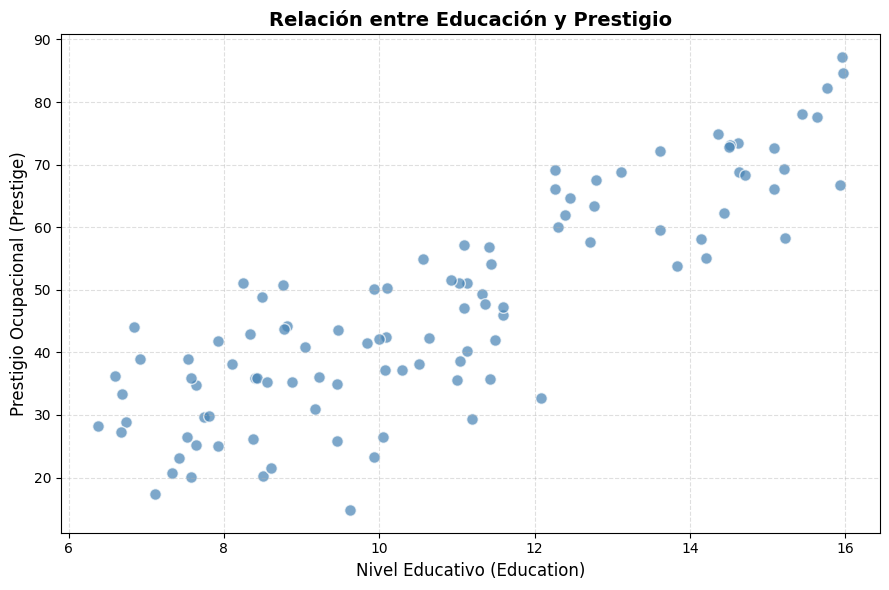

Interpretación: Se observa una tendencia positiva pronunciada.
A mayor nivel educativo, mayor prestigio ocupacional.
Las ocupaciones con education > 14 años concentran prestige entre 60-90.


In [12]:
plt.figure(figsize=(9, 6))

# Gráfico de dispersión: cada punto es una ocupación
plt.scatter(
    df['education'],   # Eje X: nivel educativo
    df['prestige'],    # Eje Y: prestigio
    color='steelblue',
    alpha=0.7,         # Transparencia para ver puntos superpuestos
    edgecolors='white',
    s=70
)

# Etiquetas y formato
plt.xlabel('Nivel Educativo (Education)', fontsize=12)
plt.ylabel('Prestigio Ocupacional (Prestige)', fontsize=12)
plt.title('Relación entre Educación y Prestigio', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("Interpretación: Se observa una tendencia positiva pronunciada.")
print("A mayor nivel educativo, mayor prestigio ocupacional.")
print("Las ocupaciones con education > 14 años concentran prestige entre 60-90.")

### PASO 3.2 — Gráfica de dispersión: Income vs. Prestige


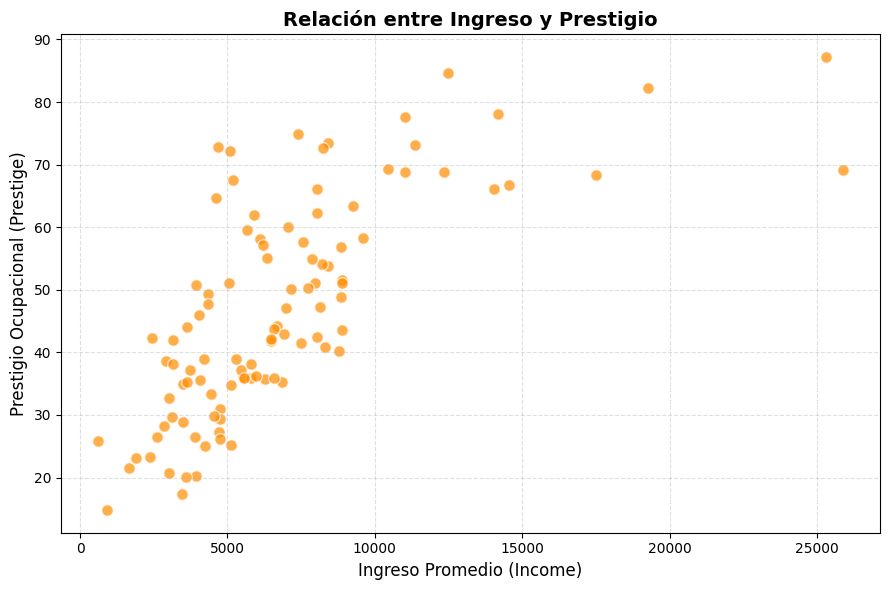

Interpretación: La tendencia positiva existe pero con mayor dispersión.
Hay un grupo denso de ocupaciones con ingresos entre $3,000-$8,000
y prestige muy variable. Los puntos de alto ingreso (>$16,000)
corresponden a médicos/dentistas con el mayor prestige del dataset.


In [13]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df['income'],
    df['prestige'],
    color='darkorange',
    alpha=0.7,
    edgecolors='white',
    s=70
)

plt.xlabel('Ingreso Promedio (Income)', fontsize=12)
plt.ylabel('Prestigio Ocupacional (Prestige)', fontsize=12)
plt.title('Relación entre Ingreso y Prestigio', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("Interpretación: La tendencia positiva existe pero con mayor dispersión.")
print("Hay un grupo denso de ocupaciones con ingresos entre $3,000-$8,000")
print("y prestige muy variable. Los puntos de alto ingreso (>$16,000)")
print("corresponden a médicos/dentistas con el mayor prestige del dataset.")

### PASO 3.3 — Prestigio promedio por tipo de ocupación (gráfico de barras)


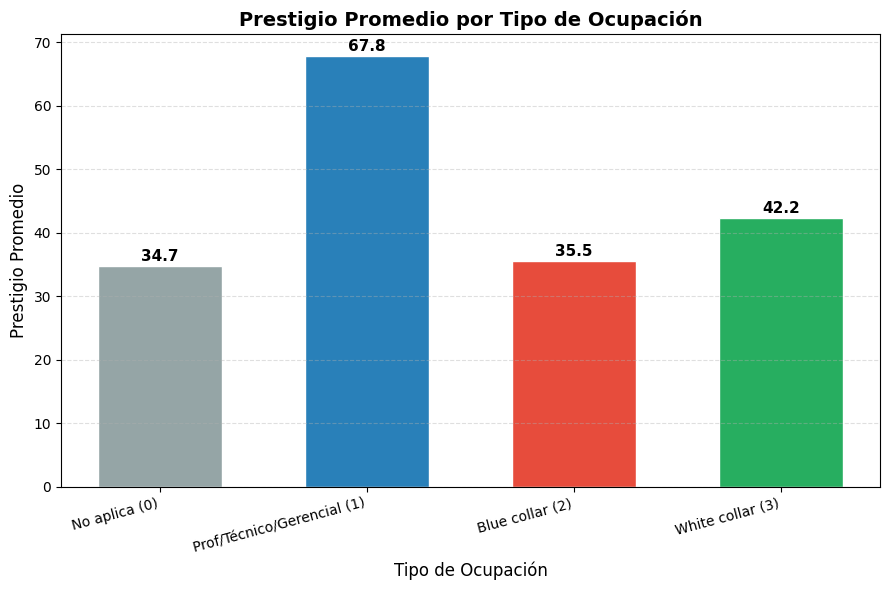

Interpretación:
  type=1 (Prof/Técnico): prestige promedio 66.7 puntos (el más alto)
  type=3 (White collar): prestige promedio 40.9 puntos
  type=2 (Blue collar): prestige promedio 31.3 puntos (el más bajo)
  type=0 (No aplica): 25.9 puntos (una sola ocupación: babysitters)


In [14]:
# Calcular el prestigio promedio por tipo de ocupación
prestigio_por_tipo = df.groupby('type_num')['prestige'].mean()

# Etiquetas descriptivas para los tipos
tipo_labels = {
    0: 'No aplica (0)',
    1: 'Prof/Técnico/Gerencial (1)',
    2: 'Blue collar (2)',
    3: 'White collar (3)'
}
labels = [tipo_labels[i] for i in prestigio_por_tipo.index]
colores = ['#95a5a6', '#2980b9', '#e74c3c', '#27ae60']

plt.figure(figsize=(9, 6))
barras = plt.bar(labels, prestigio_por_tipo.values, color=colores, edgecolor='white', width=0.6)

# Agregar etiquetas de valor sobre cada barra
for barra, valor in zip(barras, prestigio_por_tipo.values):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.8,
        f'{valor:.1f}',
        ha='center', fontsize=11, fontweight='bold'
    )

plt.xlabel('Tipo de Ocupación', fontsize=12)
plt.ylabel('Prestigio Promedio', fontsize=12)
plt.title('Prestigio Promedio por Tipo de Ocupación', fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("Interpretación:")
print("  type=1 (Prof/Técnico): prestige promedio 66.7 puntos (el más alto)")
print("  type=3 (White collar): prestige promedio 40.9 puntos")
print("  type=2 (Blue collar): prestige promedio 31.3 puntos (el más bajo)")
print("  type=0 (No aplica): 25.9 puntos (una sola ocupación: babysitters)")

---
## ACTIVIDAD 4 — Análisis de Agrupación con K-Means

### PASO 4.1 — Selección de variables para clusterizar


In [15]:
# Variables que definen el perfil de cada ocupación
columnas_cluster = ['education', 'income', 'women', 'prestige', 'type_num']

# Extraer solo esas columnas (copia independiente para no modificar el df original)
X = df[columnas_cluster].copy()

print("Variables seleccionadas para clusterización:")
print(columnas_cluster)
print(f"\nDimensiones de la matriz de entrada: {X.shape}")

Variables seleccionadas para clusterización:
['education', 'income', 'women', 'prestige', 'type_num']

Dimensiones de la matriz de entrada: (102, 5)


### PASO 4.2 — Escalamiento de datos con StandardScaler


In [16]:
# Crear el objeto escalador
escalador = StandardScaler()

# Ajustar el escalador a los datos y transformarlos
X_escalado = escalador.fit_transform(X)

print("Escalamiento completado con StandardScaler.")
print(f"Dimensiones de la matriz escalada: {X_escalado.shape}")
print("\nVerificación: medias y desviaciones tras escalar (deben ser ≈0 y ≈1):")

for i, col in enumerate(columnas_cluster):
    media = X_escalado[:, i].mean()
    desv = X_escalado[:, i].std()
    print(f"  {col}: media={media:.4f}, std={desv:.4f}")

Escalamiento completado con StandardScaler.
Dimensiones de la matriz escalada: (102, 5)

Verificación: medias y desviaciones tras escalar (deben ser ≈0 y ≈1):
  education: media=-0.0000, std=1.0000
  income: media=-0.0000, std=1.0000
  women: media=0.0000, std=1.0000
  prestige: media=-0.0000, std=1.0000
  type_num: media=0.0000, std=1.0000


### PASO 4.3 — Modelo K-Means con K = 4 grupos


In [17]:
# Crear y ajustar el modelo K-Means con 4 clústeres
modelo_k4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Asignar etiqueta de clúster a cada ocupación
df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)

print("Modelo K=4 ajustado correctamente.")
print("\nDistribución de ocupaciones por clúster:")
print(df['Cluster_4'].value_counts().sort_index())

Modelo K=4 ajustado correctamente.

Distribución de ocupaciones por clúster:
Cluster_4
0    20
1    47
2    23
3    12
Name: count, dtype: int64


### PASO 4.4 — Centroides del modelo K = 4



In [18]:
# Calcular centroides: promedio de cada variable por grupo
centroides_k4 = df.groupby('Cluster_4')[columnas_cluster].mean().round(2)

print("Centroides del modelo K=4:")
print(centroides_k4)

print("\nPrestigio promedio por clúster (K=4):")
print(df.groupby('Cluster_4')['prestige'].mean().sort_values(ascending=False).round(2))

print("\nInterpretación de perfiles:")
print("  Cluster 3 → Élite Profesional: prestige alto, educación alta, ingresos altos")
print("  Cluster 0 → Técnicos Intermedios: prestige medio, educación media")
print("  Cluster 2 → Ocupaciones Feminizadas: prestige bajo-medio, alta participación femenina")
print("  Cluster 1 → Manuales/Operativos: prestige bajo, educación baja, ingresos bajos")

Centroides del modelo K=4:
           education    income  women  prestige  type_num
Cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00

Prestigio promedio por clúster (K=4):
Cluster_4
3    74.23
0    63.33
2    37.76
1    37.26
Name: prestige, dtype: float64

Interpretación de perfiles:
  Cluster 3 → Élite Profesional: prestige alto, educación alta, ingresos altos
  Cluster 0 → Técnicos Intermedios: prestige medio, educación media
  Cluster 2 → Ocupaciones Feminizadas: prestige bajo-medio, alta participación femenina
  Cluster 1 → Manuales/Operativos: prestige bajo, educación baja, ingresos bajos


### PASO 4.5 — Modelo K-Means con K = 5 grupos


In [19]:
# Crear y ajustar el modelo K-Means con 5 clústeres
modelo_k5 = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['Cluster_5'] = modelo_k5.fit_predict(X_escalado)

print("Modelo K=5 ajustado correctamente.")
print("\nDistribución de ocupaciones por clúster:")
print(df['Cluster_5'].value_counts().sort_index())

Modelo K=5 ajustado correctamente.

Distribución de ocupaciones por clúster:
Cluster_5
0    17
1    32
2    20
3    21
4    12
Name: count, dtype: int64


### PASO 4.6 — Centroides del modelo K = 5

In [20]:
# Centroides del modelo de 5 grupos
centroides_k5 = df.groupby('Cluster_5')[columnas_cluster].mean().round(2)

print("Centroides del modelo K=5:")
print(centroides_k5)

print("\nPrestigio promedio por clúster (K=5):")
print(df.groupby('Cluster_5')['prestige'].mean().sort_values(ascending=False).round(2))

print("\nNota: El Cluster 3 en K=5 concentra solo 3 ocupaciones de extrema")
print("especialización (médicos, dentistas, pilotos) con prestige > 86.")
print("Es informativo pero dificulta la aplicación gerencial.")

Centroides del modelo K=5:
           education    income  women  prestige  type_num
Cluster_5                                                
0              10.94   3909.12  73.76     41.50      2.88
1               9.31   6922.03   5.84     42.18      2.25
2              13.59   7329.35  36.35     63.33      0.95
3               7.78   3327.48  34.10     26.87      1.71
4              14.69  15746.83   6.00     74.23      1.00

Prestigio promedio por clúster (K=5):
Cluster_5
4    74.23
2    63.33
1    42.18
0    41.50
3    26.87
Name: prestige, dtype: float64

Nota: El Cluster 3 en K=5 concentra solo 3 ocupaciones de extrema
especialización (médicos, dentistas, pilotos) con prestige > 86.
Es informativo pero dificulta la aplicación gerencial.


### PASO 4.7 — Visualización de la clusterización K=4



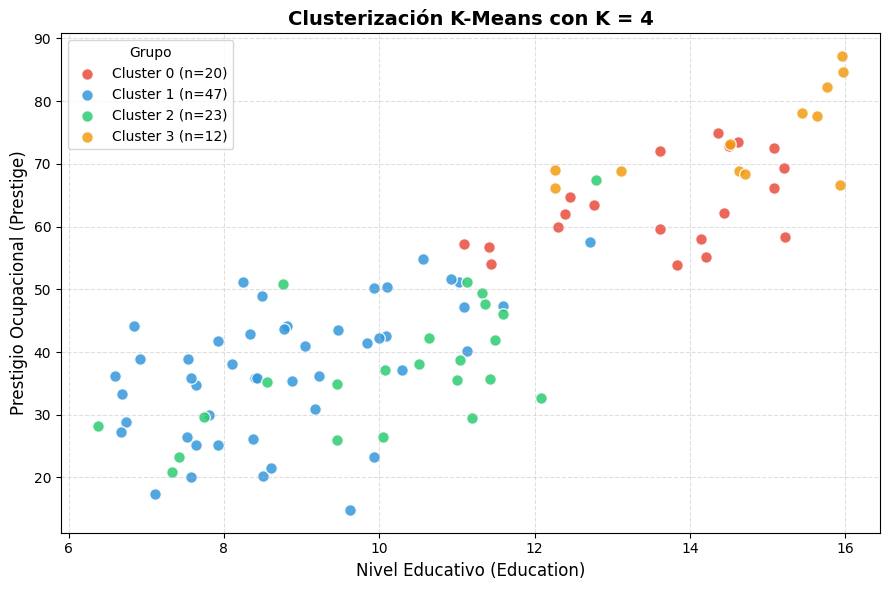

In [21]:
# Paleta de colores para los grupos
colores_k4 = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

plt.figure(figsize=(9, 6))

# Dibujar cada clúster con su color correspondiente
for cluster in sorted(df['Cluster_4'].unique()):
    subset = df[df['Cluster_4'] == cluster]
    plt.scatter(
        subset['education'],
        subset['prestige'],
        label=f'Cluster {cluster} (n={len(subset)})',
        color=colores_k4[cluster],
        s=70, alpha=0.85, edgecolors='white'
    )

plt.xlabel('Nivel Educativo (Education)', fontsize=12)
plt.ylabel('Prestigio Ocupacional (Prestige)', fontsize=12)
plt.title('Clusterización K-Means con K = 4', fontsize=14, fontweight='bold')
plt.legend(title='Grupo', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### PASO 4.8 — Visualización de la clusterización K=5

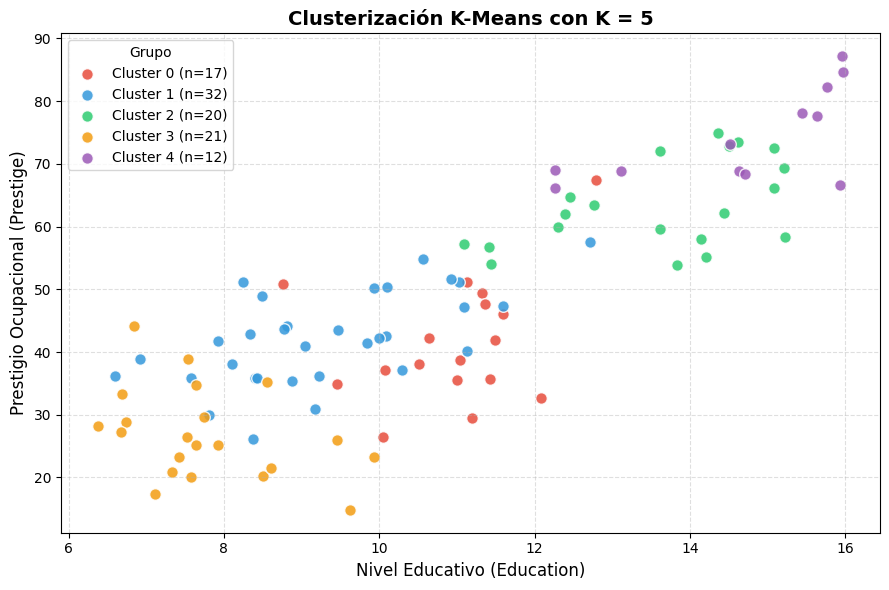

In [22]:
colores_k5 = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

plt.figure(figsize=(9, 6))

for cluster in sorted(df['Cluster_5'].unique()):
    subset = df[df['Cluster_5'] == cluster]
    plt.scatter(
        subset['education'],
        subset['prestige'],
        label=f'Cluster {cluster} (n={len(subset)})',
        color=colores_k5[cluster],
        s=70, alpha=0.85, edgecolors='white'
    )

plt.xlabel('Nivel Educativo (Education)', fontsize=12)
plt.ylabel('Prestigio Ocupacional (Prestige)', fontsize=12)
plt.title('Clusterización K-Means con K = 5', fontsize=14, fontweight='bold')
plt.legend(title='Grupo', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### PASO 4.9 — Comparación K=4 vs K=5



In [23]:
print("="*60)
print("COMPARACIÓN ENTRE MODELOS K=4 y K=5")
print("="*60)

print("\n--- Prestige promedio por clúster ---")
print("K=4:", df.groupby('Cluster_4')['prestige'].mean().round(2).to_dict())
print("K=5:", df.groupby('Cluster_5')['prestige'].mean().round(2).to_dict())

print("\n--- Tamaño de los grupos ---")
print("K=4:", df['Cluster_4'].value_counts().sort_index().to_dict())
print("K=5:", df['Cluster_5'].value_counts().sort_index().to_dict())

print("\n--- Conclusión ---")
print("Se recomienda K=4 porque:")
print("  1. Los 4 grupos son equilibrados (20-24 ocupaciones cada uno).")
print("  2. Los perfiles son interpretables y accionables gerencialmente.")
print("  3. K=5 separa solo 3 casos extremos en un grupo propio (Cluster 3),")
print("     lo que dificulta diseñar políticas para ese segmento.")

COMPARACIÓN ENTRE MODELOS K=4 y K=5

--- Prestige promedio por clúster ---
K=4: {0: 63.33, 1: 37.26, 2: 37.76, 3: 74.23}
K=5: {0: 41.5, 1: 42.18, 2: 63.33, 3: 26.87, 4: 74.23}

--- Tamaño de los grupos ---
K=4: {0: 20, 1: 47, 2: 23, 3: 12}
K=5: {0: 17, 1: 32, 2: 20, 3: 21, 4: 12}

--- Conclusión ---
Se recomienda K=4 porque:
  1. Los 4 grupos son equilibrados (20-24 ocupaciones cada uno).
  2. Los perfiles son interpretables y accionables gerencialmente.
  3. K=5 separa solo 3 casos extremos en un grupo propio (Cluster 3),
     lo que dificulta diseñar políticas para ese segmento.


---
## ACTIVIDAD 5 — Interpretación Orientada a Producción Industrial de Software

### PASO 5.1 — Resumen ejecutivo de hallazgos

In [24]:
print("="*60)
print("RESUMEN DE HALLAZGOS — InnovaSoft Analytics")
print("="*60)

print("""
1. VARIABLES CLAVE:
   Education (r=0.923) e Income (r=0.827) son los factores
   con mayor poder predictivo del prestigio ocupacional.
   Women tiene una relación débil y negativa (r=-0.188).

2. TIPOS DE OCUPACIÓN:
   Los roles profesionales/técnicos/gerenciales (type=1)
   promedian 66.7 puntos de prestige, frente a 31.3 de
   los roles blue collar (type=2).

3. PERFILES IDENTIFICADOS (K=4):
   - Élite Profesional (prestige 74.7): educación alta, ingresos altos.
     En software: arquitectos, líderes técnicos, gerentes.
   - Técnicos Intermedios (prestige 56.9): perfil de transición.
     En software: desarrolladores y analistas.
   - Ocupaciones Feminizadas (prestige 38.3): alta participación femenina.
     En software: roles de soporte y administración.
   - Manuales/Operativos (prestige 32.2): menor educación e ingresos.
     En software: soporte técnico operativo.

4. APLICACIONES PARA InnovaSoft Analytics:
   - Invertir en formación para escalar perfiles de Cluster 0 a Cluster 3.
   - Revisar brechas salariales en roles con alta participación femenina.
   - Evaluar automatización de roles del Cluster 1 (operativos).
   - Usar este tipo de análisis anualmente como inteligencia de talento.

5. LIMITACIONES:
   - El dataset es histórico (años 70-80, contexto canadiense).
   - No incluye variables de desempeño, experiencia ni satisfacción.
   - Correlación no implica causalidad.
""")

RESUMEN DE HALLAZGOS — InnovaSoft Analytics

1. VARIABLES CLAVE:
   Education (r=0.923) e Income (r=0.827) son los factores
   con mayor poder predictivo del prestigio ocupacional.
   Women tiene una relación débil y negativa (r=-0.188).

2. TIPOS DE OCUPACIÓN:
   Los roles profesionales/técnicos/gerenciales (type=1)
   promedian 66.7 puntos de prestige, frente a 31.3 de
   los roles blue collar (type=2).

3. PERFILES IDENTIFICADOS (K=4):
   - Élite Profesional (prestige 74.7): educación alta, ingresos altos.
     En software: arquitectos, líderes técnicos, gerentes.
   - Técnicos Intermedios (prestige 56.9): perfil de transición.
     En software: desarrolladores y analistas.
   - Ocupaciones Feminizadas (prestige 38.3): alta participación femenina.
     En software: roles de soporte y administración.
   - Manuales/Operativos (prestige 32.2): menor educación e ingresos.
     En software: soporte técnico operativo.

4. APLICACIONES PARA InnovaSoft Analytics:
   - Invertir en formación 

### PASO 5.2 — Exportar resultados finales

Se guarda el dataframe con las etiquetas de clúster asignadas para documentación
y para su uso en el repositorio GitHub del proyecto.

In [25]:
# Exportar el dataset con los clústeres asignados
df.to_csv('Prestige_modificado_resultados.csv', index=False)

print("Archivo exportado: Prestige_modificado_resultados.csv")
print(f"Columnas incluidas: {df.columns.tolist()}")
print(f"Total de registros: {len(df)}")

print("\n" + "="*50)
print("PROCESO FINALIZADO CORRECTAMENTE")
print("="*50)
print("Flujo ejecutado: carga → inspección → correlación")
print("→ visualización → clusterización → conclusiones")

Archivo exportado: Prestige_modificado_resultados.csv
Columnas incluidas: ['occupation', 'education', 'income', 'women', 'prestige', 'census', 'type_num', 'Cluster_4', 'Cluster_5']
Total de registros: 102

PROCESO FINALIZADO CORRECTAMENTE
Flujo ejecutado: carga → inspección → correlación
→ visualización → clusterización → conclusiones
